# Lab 02 - Open the box

Week 2 · AI course · Narxoz University · about 50 minutes · **no API key**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/unreal-kz/lab-02-AI-course/blob/main/lab02_inside_the_model.ipynb)

Lecture 3 told you what happens inside a language model. Today you check it, on a real model:
GPT-2 small, 124 million parameters, released in 2019. It runs on the free CPU that Colab gives you.
Three claims from the lecture get tested:

1. The output is not a word. It is a list of 50,257 probabilities.
2. Temperature reshapes that list. It cannot change which token is first. Top-p is a different operation.
3. Attention is a table of weights, and every row of it sums to one.

**The rule of this lab, inherited from Lab 01: write your prediction down *before* you run the cell.**
A prediction you did not write down is a prediction you will not remember getting wrong.

**Right now, run the next cell only** (click it, press Shift+Enter). It downloads the model while the
lecture continues. Do **not** use *Run all*: it would show you every answer before you have predicted it.
If a warning about `HF_TOKEN` appears, ignore it - the model is public.


In [1]:
import importlib.util
import subprocess
import sys

# Colab normally has all three already; this installs whatever is missing.
for pkg in ("torch", "transformers", "matplotlib"):
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

import math

import matplotlib.pyplot as plt
import torch
import transformers
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL = "openai-community/gpt2"

tok = AutoTokenizer.from_pretrained(MODEL)
# attn_implementation="eager" is required for Part 2: the default "sdpa" kernel never
# returns attention weights, so output_attentions=True would give you nothing.
model = AutoModelForCausalLM.from_pretrained(MODEL, attn_implementation="eager")
model.eval()

cfg = model.config
print(f"torch {torch.__version__} | transformers {transformers.__version__}")
print(f"parameters      : {sum(p.numel() for p in model.parameters()):,}")
print(f"vocabulary      : {cfg.vocab_size:,} tokens")
print(f"layers x heads  : {cfg.n_layer} x {cfg.n_head}")
print(f"embedding table : {tuple(model.transformer.wte.weight.shape)}  (rows = tokens, columns = numbers per token; 768 is the GPT-2 small figure from slide 10)")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

torch 2.11.0+cpu | transformers 5.16.1
parameters      : 124,439,808
vocabulary      : 50,257 tokens
layers x heads  : 12 x 12
embedding table : (50257, 768)  (rows = tokens, columns = numbers per token; 768 is the GPT-2 small figure from slide 10)


## Part 0 - a token is not a word (4 min)

Lecture 3 measured six tokenizers. GPT-2's is the seventh, and the smallest: 50,257 entries, against
100,277 (cl100k), 128,000 (Llama 3) and 200,019 (o200k).

**✏️ Predict first.** The Kazakh word `бөлімшеңізде` took 12 tokens on cl100k and 7 on o200k.
How many will it take on GPT-2: more than 12, fewer, or the same? Write your number here:

> **Prediction:** Я думаю что больше 12, так как словарь GPT-2 меньше остальных

In [2]:
def show_tokens(text: str) -> None:
    ids = tok.encode(text)
    print(f"{text!r}: {len(ids)} tokens")
    print("  ids   :", ids)
    print("  pieces:", tok.convert_ids_to_tokens(ids))


for word in ["restore", "bank", "банк", "бөлімшеңізде"]:
    show_tokens(word)

'restore': 2 tokens
  ids   : [2118, 382]
  pieces: ['rest', 'ore']
'bank': 1 tokens
  ids   : [17796]
  pieces: ['bank']
'банк': 5 tokens
  ids   : [140, 109, 16142, 22177, 31583]
  pieces: ['Ð', '±', 'Ð°', 'Ð½', 'Ðº']
'бөлімшеңізде': 19 tokens
  ids   : [140, 109, 143, 102, 30143, 141, 244, 43108, 141, 230, 16843, 142, 96, 141, 244, 140, 115, 43666, 16843]
  pieces: ['Ð', '±', 'Ó', '©', 'Ð»', 'Ñ', 'ĸ', 'Ð¼', 'Ñ', 'Ī', 'Ðµ', 'Ò', '£', 'Ñ', 'ĸ', 'Ð', '·', 'Ð´', 'Ðµ']


`Ġ` in a piece means "this token starts with a space". The odd letters (`Ð`, `±` …) are single **bytes**
of a Cyrillic letter, printed as if they were characters - the same thing lecture slide 5 showed for `ө`.

**✏️ Your answer.** In the lecture's board derivation, three merges turned `банк` into one token.
GPT-2 needed several tokens for it. Using what slide 6 taught about where merges come from, why?

> **Answer:** Токенизатор GPT-2 обучался в основном на английских текстах, поэтому он "выучил" много готовых сочетаний букв именно для английского - например, "bank" стал одним токеном. А русского текста в обучении было мало, поэтому для типичных русских буквосочетаний ("ба", "ан" и т.д.) готовых объединений не появилось. Из-за этого каждая буква "банк" осталась отдельным токеном (точнее, даже каждый байт буквы). Дело не в том, что русский язык сам по себе сложнее - просто модель его почти не видела, когда училась.

## Part 1 - the output is 50,257 numbers (10 min)

Slide 14: the model does not output a word. It outputs one score (a *logit*) for every token in its
vocabulary, and softmax turns the scores into probabilities.

**✏️ Predict first.** For the prompt

`The capital of Kazakhstan is Astana. The capital of France is`

what is GPT-2's most likely next token, and roughly what probability does it get? And do the ten
most likely tokens together hold more than 90% of all the probability, or less?

> **Prediction:** Скорее всего, следующим токеном будет " Paris" - модель уже видела похожий паттерн "столица X это Y" в первом предложении. Вероятность, наверное, 30-50%. Топ-10 токенов вместе, думаю, держат больше 90%, потому что это довольно предсказуемый факт.

In [3]:
@torch.no_grad()
def next_token_logits(prompt: str) -> torch.Tensor:
    """Scores for every token in the vocabulary as the continuation of `prompt`."""
    enc = tok(prompt, return_tensors="pt")
    return model(**enc).logits[0, -1]  # shape: (50257,)


def show_next_token(prompt: str, k: int = 10, T: float = 1.0) -> None:
    logits = next_token_logits(prompt)
    probs = torch.softmax(logits / T, dim=-1)
    top = torch.topk(probs, k)
    held = top.values.sum().item()
    print(f"prompt: {prompt!r}   T={T}")
    print(f"logits shape: {tuple(logits.shape)}   probabilities sum to {probs.sum().item():.4f}")
    for p, i in zip(top.values, top.indices):
        print(f"  {p.item():6.2%}   id {i.item():>6}   {tok.decode([i.item()])!r}")
    print(f"  top-{k} hold {held:.1%}; the other {probs.numel() - k:,} tokens share {1 - held:.1%}")


PROMPT = "The capital of Kazakhstan is Astana. The capital of France is"
show_next_token(PROMPT)

prompt: 'The capital of Kazakhstan is Astana. The capital of France is'   T=1.0
logits shape: (50257,)   probabilities sum to 1.0000
  22.87%   id   8304   ' Ast'
  22.08%   id   6342   ' Paris'
   4.48%   id    262   ' the'
   3.15%   id  18460   ' Nice'
   2.56%   id   4881   ' France'
   2.15%   id  31630   ' Monaco'
   1.97%   id   9281   ' Saint'
   1.95%   id  45996   ' Marse'
   1.51%   id  35193   ' Lyon'
   1.23%   id    347   ' B'
  top-10 hold 64.0%; the other 50,247 tokens share 36.0%


In [5]:
MY_PROMPTS = [
    "Ерте ерте ерте де",
    "Друг с другом",
    "3 + 2 =",
]

for p in MY_PROMPTS:
    show_next_token(p, k=5)
    print()


def prob_of(prompt: str, text: str) -> float:
    """Probability that the FIRST token of `text` comes next after `prompt`."""
    probs = torch.softmax(next_token_logits(prompt), dim=-1)
    return probs[tok.encode(text)[0]].item()


print("P(' Paris') =", f"{prob_of(PROMPT, ' Paris'):.4f}")
print("P('Paris')  =", f"{prob_of(PROMPT, 'Paris'):.6f}")

prompt: 'Ерте ерте ерте де'   T=1.0
logits shape: (50257,)   probabilities sum to 1.0000
  16.38%   id  21169   'р'
  13.46%   id  30143   'л'
  12.96%   id    140   '�'
  10.65%   id  38857   'в'
   9.63%   id  22177   'н'
  top-5 hold 63.1%; the other 50,252 tokens share 36.9%

prompt: 'Друг с другом'   T=1.0
logits shape: (50257,)   probabilities sum to 1.0000
  25.36%   id    220   ' '
  22.05%   id  12466   ' �'
   8.03%   id  16142   'а'
   7.82%   id  18849   'и'
   5.79%   id  35072   'у'
  top-5 hold 69.0%; the other 50,252 tokens share 31.0%

prompt: '3 + 2 ='   T=1.0
logits shape: (50257,)   probabilities sum to 1.0000
   8.62%   id    352   ' 1'
   8.53%   id    513   ' 3'
   7.41%   id    362   ' 2'
   7.03%   id    657   ' 0'
   5.02%   id    604   ' 4'
  top-5 hold 36.6%; the other 50,252 tokens share 63.4%

P(' Paris') = 0.2208
P('Paris')  = 0.000009


**✏️ Your answers.**

1. Look at the last two lines. Same word, different probability. Why? (Run `show_tokens(" Paris")` and `show_tokens("Paris")` if you need to see it.)
2. Was your prediction right? Is the most likely token the *correct* answer to the question in the prompt? Then what does "the model's answer" actually mean?

> **1.** Потому что " Paris" и "Paris" для модели - это два разных токена, у них разные номера в словаре. В текстах, на которых училась модель, слово "Paris" почти всегда встречалось после пробела, как обычное слово. А слитно, без пробела, оно почти не попадалось. Поэтому модель уверенно предсказывает вариант с пробелом, а без пробела - почти никогда.
>
> **2.** Нет, не угадал, модель выбрала " Ast", а не " Paris", хотя они почти на равных (22.87% против 22.08%). И даже если бы она выбрала правильный город, это не значит, что модель "знает" ответ - она просто ставит на самое частое продолжение текста, а не думает и не проверяет факты. Получается, "ответ модели" - это не факт, а просто самый вероятный следующий кусок текста.

### Temperature

Slide 14 claimed: temperature divides every logit by `T` before softmax. That **reshapes** the distribution
but cannot change which token is first.

**✏️ Predict first.** As `T` goes 0.25 → 1 → 2 → 5, will the #1 token change at some point?
And what will happen to its probability?

> **Prediction:** Думаю, #1 токен не поменяется ни при каком T, потому что температура просто делит все числа на одно и то же значение — это не меняет, какое число было самым большим. А вероятность самого вероятного токена, скорее всего, будет падать по мере роста T — распределение станет более "размазанным", менее уверенным.

In [6]:
def entropy_nats(log_probs: torch.Tensor) -> float:
    """Entropy of a distribution given as log-probabilities (avoids 0 * log 0 = nan)."""
    return -(log_probs.exp() * log_probs).sum().item()


logits = next_token_logits(PROMPT)
print(f"maximum possible entropy (all {cfg.vocab_size:,} tokens equally likely): {math.log(cfg.vocab_size):.3f} nats\n")
print(f"{'T':>5}  {'#1 token':<10} {'p(#1)':>8} {'entropy':>9}   same #1 as at T=1?")
ref = logits.argmax().item()
for T in [0.25, 1.0, 2.0, 5.0]:
    log_probs = torch.log_softmax(logits / T, dim=-1)
    top1 = log_probs.argmax().item()
    print(f"{T:>5}  {tok.decode([top1])!r:<10} {log_probs[top1].exp().item():>8.4f} {entropy_nats(log_probs):>9.3f}   {top1 == ref}")

maximum possible entropy (all 50,257 tokens equally likely): 10.825 nats

    T  #1 token      p(#1)   entropy   same #1 as at T=1?
 0.25  ' Ast'       0.5345     0.700   True
  1.0  ' Ast'       0.2287     4.120   True
  2.0  ' Ast'       0.0123     9.114   True
  5.0  ' Ast'       0.0004    10.547   True


**✏️ Your answers.**

1. Did the #1 token ever change? Why can it not? (Hint: what does dividing every score by the same positive number do to their *order*?)
2. Temperature 0 means "always pick the #1 token". Is that token the right answer for this prompt? What does this say about the advice "set the temperature to 0 to make the model reliable"?

> **1.** Нет, #1 токен не менялся ни разу, оставался ' Ast' при всех значениях T. Он не может измениться, потому что деление всех чисел на одно и то же положительное число не меняет их порядок — кто был больше всех, тот и останется больше всех после деления.
>
> **2.** Нет, это не правильный ответ — правильный ответ " Paris", а модель на первом месте выдаёт " Ast". Значит совет "поставь температуру 0, и модель будет надёжной" неверный — температура 0 просто заставляет модель всегда выбирать самый вероятный токен, но если сам этот токен неправильный, температура тут не поможет. Она делает ответ предсказуемым (одинаковым каждый раз), а не правильным.

### Top-p

Top-p does something different: it **deletes** the tail. Keep the smallest set of most likely tokens whose
probabilities add up to `p`, set everything else to exactly zero, renormalise.

In [7]:
def top_p_filter(probs: torch.Tensor, top_p: float = 0.9) -> torch.Tensor:
    """Keep the smallest set of top tokens with total probability >= top_p; zero the rest; renormalise."""
    sorted_p, sorted_idx = torch.sort(probs, descending=True)
    cum = torch.cumsum(sorted_p, dim=-1)
    keep = (cum - sorted_p) < top_p  # keep a token while the mass BEFORE it is still below top_p
    kept = torch.zeros_like(probs)
    kept[sorted_idx[keep]] = sorted_p[keep]
    return kept / kept.sum()


print(f"{'T':>5}  {'tokens kept by top-p=0.9':>25}  {'p(#1) before':>13}  {'p(#1) after':>12}")
for T in [0.25, 1.0, 5.0]:
    probs = torch.softmax(logits / T, dim=-1)
    kept = top_p_filter(probs, 0.9)
    print(f"{T:>5}  {(kept > 0).sum().item():>25,}  {probs.max().item():>13.4f}  {kept.max().item():>12.4f}")


def sample(probs: torch.Tensor, n: int = 10, seed: int = 0) -> list[str]:
    g = torch.Generator().manual_seed(seed)
    return [tok.decode([i.item()]) for i in torch.multinomial(probs, n, replacement=True, generator=g)]


print()
for T in [0.25, 1.0, 5.0]:
    print(f"T={T:<5} 10 samples:", sample(torch.softmax(logits / T, dim=-1)))
print("T=1.0   + top-p 0.9:", sample(top_p_filter(torch.softmax(logits, dim=-1), 0.9)))

    T   tokens kept by top-p=0.9   p(#1) before   p(#1) after
 0.25                          2         0.5345        0.5351
  1.0                        341         0.2287        0.2541
  5.0                     35,021         0.0004        0.0004

T=0.25  10 samples: [' Ast', ' Ast', ' Paris', ' Ast', ' Ast', ' Ast', ' Paris', ' Paris', ' Ast', ' Paris']
T=1.0   10 samples: [' Siem', ' Ast', ' Paris', ' Monaco', ' Ast', ' Lie', ' Pr', ' Paris', ' Ast', ' Paris']
T=5.0   10 samples: [' Catalyst', ' Shim', ' offline', ' alienation', ' hangs', ' Deutsche', ' Mexico', ' "[', ' Actions', ' stability']
T=1.0   + top-p 0.9: [' Mé', ' Ast', ' Paris', ' Monaco', ' Ast', ' Saint', ' Or', ' Paris', ' Ast', ' Paris']


**✏️ Your answer.** In your own words, one sentence each: what does temperature do to the distribution,
and what does top-p do? Why is "reshape" not the same as "delete"?

> **Temperature:**  Температура меняет форму распределения — делает его более резким (при низком T) или более плоским (при высоком T), но не выбрасывает ни один токен полностью, у каждого остаётся хоть какая-то вероятность.
>
> **Top-p:** Top-p, наоборот, полностью обнуляет самые маловероятные токены (весь "хвост"), оставляя только минимальный набор токенов, вместе дающих нужную долю вероятности (например, 90%) — и сколько токенов останется, зависит от того, насколько модель уверена: при T=0.25 хватило 2 токенов, при T=5.0 понадобилось 35,021.

## Part 2 - attention is a table of weights (12 min)

Slide 11: `softmax(QKᵀ/√d_k)V`. The softmax produces a table: row *i* says how much token *i* looks at
each earlier token. **Every row sums to 1.** GPT-2 small has 12 layers × 12 heads = 144 such tables.
You will look at them for the same prompt you just used.

How to read a plot: **row** = the token doing the looking; **column** = the token being looked at.
The upper triangle is empty because a token cannot look at the future. GPT-2 adds no start token,
so position 0 is your first word.

13 tokens: ['The', '_capital', '_of', '_Kazakhstan', '_is', '_Ast', 'ana', '.', '_The', '_capital', '_of', '_France', '_is']
12 layers; each tensor has shape (1, 12, 13, 13) = (batch, heads, query, key)
row sums, layer 0 head 0: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


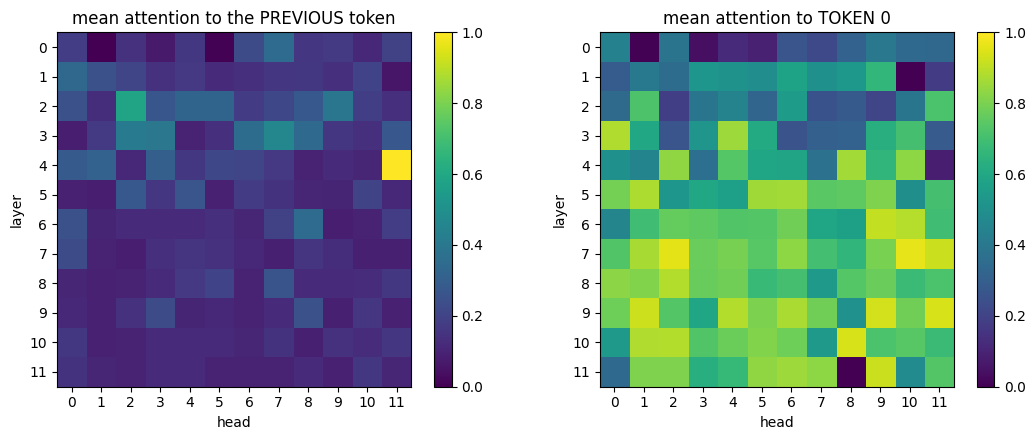

In [8]:
@torch.no_grad()
def get_attention(text: str):
    enc = tok(text, return_tensors="pt")
    out = model(**enc, output_attentions=True)
    assert out.attentions is not None and out.attentions[0] is not None, (
        "no attention weights returned: load the model with attn_implementation='eager'"
    )
    labels = [t.replace("Ġ", "_") for t in tok.convert_ids_to_tokens(enc["input_ids"][0])]
    return labels, out.attentions  # 12 tensors, each (batch=1, heads=12, n, n)


TEXT = PROMPT
labels, atts = get_attention(TEXT)
n = len(labels)
print(f"{n} tokens: {labels}")
print(f"{len(atts)} layers; each tensor has shape {tuple(atts[0].shape)} = (batch, heads, query, key)")
print("row sums, layer 0 head 0:", [round(x, 4) for x in atts[0][0, 0].sum(dim=-1).tolist()])

# For every one of the 144 heads: how much attention goes to the PREVIOUS token, and to token 0?
prev_score = torch.zeros(cfg.n_layer, cfg.n_head)
sink_score = torch.zeros(cfg.n_layer, cfg.n_head)
for L in range(cfg.n_layer):
    a = atts[L][0]  # (heads, n, n)
    prev_score[L] = torch.stack([a[:, i, i - 1] for i in range(1, n)]).mean(dim=0)
    sink_score[L] = a[:, 1:, 0].mean(dim=1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, score, title in [
    (axes[0], prev_score, "mean attention to the PREVIOUS token"),
    (axes[1], sink_score, "mean attention to TOKEN 0"),
]:
    im = ax.imshow(score.numpy(), cmap="viridis", vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xlabel("head")
    ax.set_ylabel("layer")
    ax.set_xticks(range(cfg.n_head))
    ax.set_yticks(range(cfg.n_layer))
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

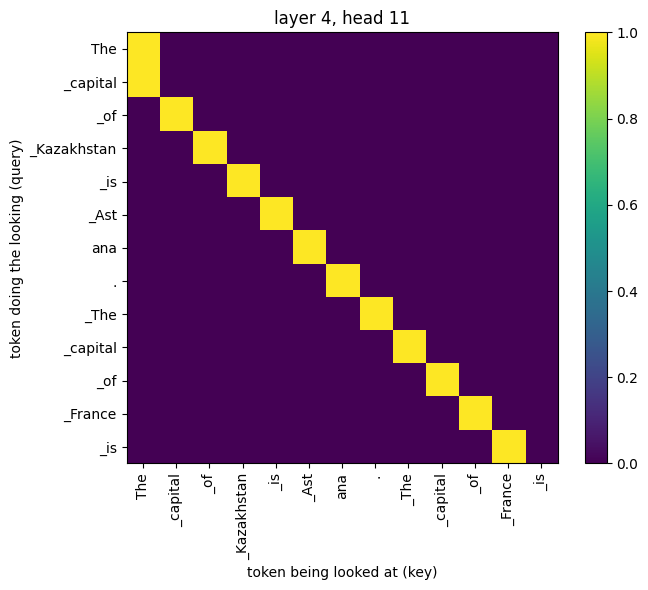

In [12]:
def attention_heatmap(text: str, layer: int, head: int) -> None:
    labels, atts = get_attention(text)
    a = atts[layer][0, head]
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(a.numpy(), cmap="viridis", vmin=0, vmax=1)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels)
    ax.set_xlabel("token being looked at (key)")
    ax.set_ylabel("token doing the looking (query)")
    ax.set_title(f"layer {layer}, head {head}")
    fig.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout()
    plt.show()


LAYER, HEAD = 4, 11
attention_heatmap(TEXT, LAYER, HEAD)

**✏️ Your answers.**

1. Read the left grid above. Which (layer, head) looks most like a "previous-token" head? Put it into `LAYER, HEAD` in the cell above and re-run it. What pattern do you see in the heatmap, and why is it a diagonal just *below* the main diagonal?
2. Does every head in that layer do the same thing?

> **1.** layer 4, head 11. На heatmap видна яркая диагональ чуть НИЖЕ главной диагонали — потому что каждый токен (строка) сильнее всего смотрит на токен прямо перед собой (предыдущую позицию). Так как токен не может "смотреть" сам на себя как на предыдущий, эта связь сдвинута на одну позицию влево от главной диагонали — отсюда и сдвиг вниз.
>
> **2.**  Нет — судя по общему графику для layer 4, только head 11 показывает результат 1.000, остальные головы в этом же слое (например, head 0-10) намного тусклее на общей картинке. Значит, каждая голова в слое специализируется на своей задаче, а не делает одно и то же.

In [10]:
# Check yourself: the three heads with the highest previous-token score for this prompt.
for v, idx in zip(*torch.topk(prev_score.flatten(), 3)):
    L, H = divmod(idx.item(), cfg.n_head)
    print(f"layer {L}, head {H}: {v.item():.3f} of its attention goes to the previous token")

layer 4, head 11: 1.000 of its attention goes to the previous token
layer 2, head 2: 0.585 of its attention goes to the previous token
layer 3, head 7: 0.462 of its attention goes to the previous token


most extreme head on the RIGHT grid: layer 7, head 10  (mean attention to token 0 = 0.964)
mean attention to token 0, averaged over the 12 heads of each layer:
   [0.25, 0.42, 0.4, 0.52, 0.57, 0.72, 0.71, 0.81, 0.74, 0.79, 0.75, 0.66]


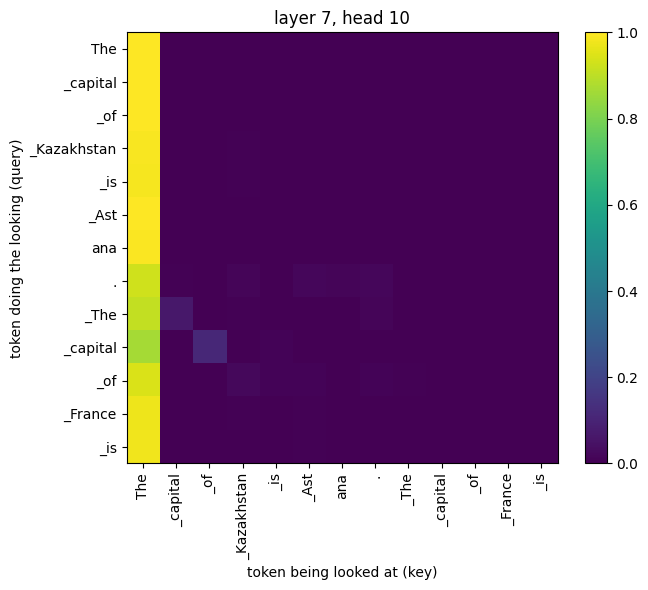

In [13]:
sink_layer, sink_head = divmod(sink_score.argmax().item(), cfg.n_head)
print(f"most extreme head on the RIGHT grid: layer {sink_layer}, head {sink_head}  "
      f"(mean attention to token 0 = {sink_score[sink_layer, sink_head]:.3f})")
print("mean attention to token 0, averaged over the 12 heads of each layer:")
print("  ", [round(x, 2) for x in sink_score.mean(dim=1).tolist()])
attention_heatmap(TEXT, sink_layer, sink_head)

### Two traps

**The bright first column.** In layers 5–10 the *average* head puts roughly 70–80% of its attention on
token 0 (measured above, for this prompt), and the most extreme head puts over 95% there. That is not
"the model is thinking about the word *The*". The usual explanation - which this lab does not test - is that a softmax
row must sum to 1, so a head with nothing useful to look at has to put its weight somewhere, and the first
token is where it goes. Either way, the bright column tells you how the mechanism is built, not what the
first word means. Which head is the most extreme one changes from text to text; the phenomenon does not.

**A weight is not an explanation.** A high attention weight says how much of a token's *value vector* is
averaged in. It does not say how much that token changed the answer. Lecture 3 cited the papers that argue
about this; the heatmap is a picture of a mechanism, not a proof of a reason.

**✏️ Your answer.** Which layers have the highest average attention to token 0? Given the trap above, would you
report "the model focuses on the first word" to a manager? What would you say instead?

> **Answer:** Судя по числам, самое высокое среднее внимание к token 0 — в слоях 5-10 (примерно 0.72-0.81), особенно layer 7 (0.81). Но я бы НЕ стал(а) говорить менеджеру "модель фокусируется на первом слове" — это неверная интерпретация. На самом деле это побочный эффект механизма softmax: каждая строка обязана суммироваться в 1, и когда голове нечего смотреть полезного, она вынуждена куда-то "слить" вес — и первый токен просто оказывается удобным местом для этого технически. Я бы сказал(а) менеджеру: "высокий вес внимания к первому токену — это особенность того, как устроен механизм, а не признак того, что модель придаёт значение первому слову по смыслу".

## Part 3 - the same model, in Kazakh (5 min)

Lecture 3's claim: Kazakh costs more because of the **table**, not the language. GPT-2's table has only
50,257 entries; how well it covers Russian and Kazakh is what you measure now. Three parallel sentences
(my translations - if you spot an error, say so):

**✏️ Predict first.** Which language needs the most tokens *per character*? Lecture 3 (slide 2) measured Kazakh at
1.7–4.8× the English token count and Russian at 1.2–2.9×, across six tokenizers. Will Kazakh be clearly worse than
Russian on GPT-2 as well?

> **Prediction:** Думаю, казахский снова окажется хуже русского по токенам на символ — так же, как было в Part 0, где казахское слово заняло намного больше токенов, чем ожидалось. GPT-2 совсем плохо покрывает казахские буквы, так что казахский должен быть заметно дороже.

In [14]:
SENTENCES = {
    "en": "The capital of Kazakhstan is Astana.",
    "ru": "Столица Казахстана - Астана.",
    "kk": "Қазақстанның астанасы - Астана.",
}

print(f"{'lang':<5}{'chars':>6}{'bytes':>7}{'tokens':>8}{'tokens/char':>13}{'x English':>11}")
en_tokens = len(tok.encode(SENTENCES["en"]))
for lang, s in SENTENCES.items():
    t = len(tok.encode(s))
    print(f"{lang:<5}{len(s):>6}{len(s.encode()):>7}{t:>8}{t / len(s):>13.2f}{t / en_tokens:>11.2f}")

lang  chars  bytes  tokens  tokens/char  x English
en       36     36       8         0.22       1.00
ru       28     51      31         1.11       3.88
kk       31     57      34         1.10       4.25


In [15]:
@torch.no_grad()
def greedy_continue(prompt: str, n_tokens: int = 20) -> str:
    """Slide 14's loop, written out: pick the #1 token, append it, repeat."""
    ids = tok(prompt, return_tensors="pt")["input_ids"]
    for _ in range(n_tokens):
        next_id = model(input_ids=ids).logits[0, -1].argmax()
        ids = torch.cat([ids, next_id.view(1, 1)], dim=1)
    return tok.decode(ids[0])


for prompt in ["The capital of Kazakhstan is", "Столица Казахстана -", "Қазақстанның астанасы -"]:
    show_next_token(prompt, k=3)
    top1 = int(next_token_logits(prompt).argmax())
    print(f"  #1 token as raw text: {tok.convert_ids_to_tokens(top1)!r}")
    print("  greedy, 20 tokens:", repr(greedy_continue(prompt)))
    print()

prompt: 'The capital of Kazakhstan is'   T=1.0
logits shape: (50257,)   probabilities sum to 1.0000
   8.98%   id    262   ' the'
   7.63%   id   1363   ' home'
   5.89%   id    257   ' a'
  top-3 hold 22.5%; the other 50,254 tokens share 77.5%
  #1 token as raw text: 'Ġthe'
  greedy, 20 tokens: "The capital of Kazakhstan is the capital of the country's former Soviet Union, and the country's president, Nursultan Nazar"

prompt: 'Столица Казахстана -'   T=1.0
logits shape: (50257,)   probabilities sum to 1.0000
  30.87%   id  12466   ' �'
   3.30%   id    220   ' '
   2.35%   id    140   '�'
  top-3 hold 36.5%; the other 50,254 tokens share 63.5%
  #1 token as raw text: 'ĠÐ'
  greedy, 20 tokens: 'Столица Казахстана - простий простий п'

prompt: 'Қазақстанның астанасы -'   T=1.0
logits shape: (50257,)   probabilities sum to 1.0000
  27.50%   id  12466   ' �'
   6.15%   id    220   ' '
   2.78%   id    140   '�'
  top-3 hold 36.4%; the other 50,254 tokens share 63.6%
  #1 token as raw tex

**✏️ Your answer.** One or two sentences. Look at the `tokens/char` column and at the #1 next token for the
Russian and Kazakh prompts. What does the model see, and why does it break? Is the problem the Kazakh
*language*, or something else? What would you change to fix it?

> **Answer:** Модель видит не слова, а куски байтов — для русского и казахского токенизатор режет буквы настолько мелко, что самый вероятный "токен" оказывается вообще сломанным байтом, а не частью слова. Поэтому генерация быстро превращается в бессмыслицу на обоих языках. Дело не в самом языке — просто токенизатор GPT-2 почти не видел русский и казахский при обучении, и у него нет готовых кусков для них, как есть для английского. Чтобы исправить, нужно не менять сам промпт, а обучить токенизатор (или всю модель) на большем количестве текстов на этих языках, либо взять другую модель, изначально обученную на нескольких языках.

## What you hand in

Download this notebook (*File → Download → .ipynb*) **after** you have run every cell and filled in every ✏️, and upload it to Canvas.

1. The four predictions (Parts 0, 1, temperature, 3), written before you ran the cell, with the measured value next to each.
2. Your one-sentence difference between temperature and top-p.
3. The (layer, head) you found for the previous-token pattern, and the (layer, head) of the most extreme "token 0" head.
4. Your Part 3 answer.

Extension tasks are in the README of this repository. They are optional.